# The goal of this notebook is to rigorously test the component spawning mechanism of the OAMFA system

#### The notebook will consist of two tests:

#### *Novel Material Spawning*
- An OAMFA will be pretrained on water and land pixels.  
- A new water and land image will be fetched, and a 64x64 square will be added to it.
- The square will consist of actual pixels, taken from another image (e.g., desert pixels).
- The model will stream the unseen water and land image containing the 64x64 square with the new signal.
- Expected outcome is for the model to spawn one new component.
- I will plot the test-image with the 64x64 square blacked out as a reference. Then I will have what component each pixel is assigned to (black if no pixel are assigned due to distance), and the Mahalanobis distance of each pixel as a heatmap.

#### *Noise Rejection*
- An OAMFA will be pretrained on water and land pixels.  
- A new water and land image will be fetched, and a 64x64 square will be added to it.
- The square will consist of noisy pixels (To mimic the band-specific noise mentioned earlier, I might add some salt and pepper noise on some of the specific bands to mimic sensor failure).
- The model will stream the unseen water and land image containing the noise 64x64 square.
- Expected outcome is for the model to spawn zero new components.
- I will plot the test-image with the 64x64 square blacked out as a reference. Then I will have what component each pixel is assigned to (black if no pixel are assigned due to distance), and the Mahalanobis distance of each pixel as a heatmap.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import glob
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from otfp import MFA_OTFP
from hypso import Hypso


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_data_dir = glob.glob(f'../data/component_spawning/*.nc')

If the test-images are not created: create them

The images are fetched from the HYPSO Portal, and the following are used: 
- HYPSO-1_HSI_20220524T182707Z-l1a.nc (training)
- HYPSO-1_HSI_20220529T190459Z-l1a.nc (testing)
- HYPSO-1_HSI_20230615T094801Z-l1a.nc (Forest pixels)

Successfully loaded svalbard_2022-05-24T18-27-07Z-l1b.nc | Shape: (956, 684, 120)
Successfully loaded mjosa_forest_2023-06-15T09-48-01Z-l1b.nc | Shape: (598, 1092, 120)
Splitting primary image in half:
New Train Shape (Top Half):     (478, 684, 120)
New Test Shape (Bottom Half):   (478, 684, 120)
Forest Source Shape:            (598, 1092, 120)


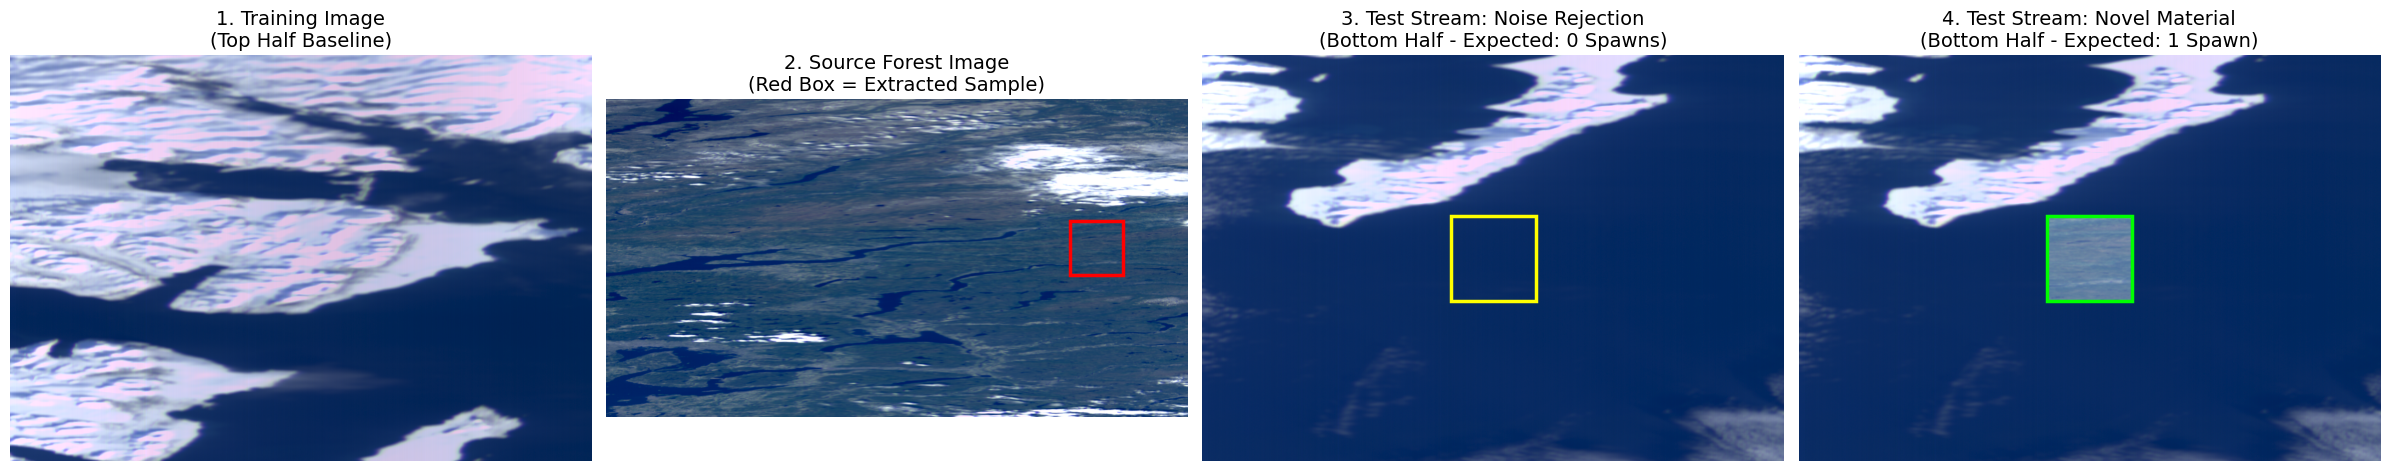

In [ ]:

# We now only need the primary Svalbard image and the Forest image
base_svalbard_path = "../data/component_spawning/svalbard_2022-05-24T18-27-07Z-l1b.nc"
forest_path = "../data/component_spawning/mjosa_forest_2023-06-15T09-48-01Z-l1b.nc"

path_list = [base_svalbard_path, forest_path]
data_dict = {}

# --- 1. Fetch the Images ---
for file_path in path_list:
    try:
        satobj = Hypso(file_path)
        cube = getattr(satobj, "l1b_cube", None)
        if cube is None:
            print(f"Skipping {file_path}: Missing l1b_cube data.")
            continue
        
        image = cube.values.astype(np.float32)
        data_dict[file_path] = image
        print(f"Successfully loaded {file_path.split('/')[-1]} | Shape: {image.shape}")
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        break

# Extract the arrays
svalbard_full = data_dict.get(base_svalbard_path)
img_forest = data_dict.get(forest_path)

# Proceed only if data successfully loaded
if svalbard_full is not None and img_forest is not None:

    # --- 1.5 The Half-and-Half Split ---
    # Split the Svalbard image horizontally (top half for training, bottom half for testing)
    mid_row = svalbard_full.shape[0] // 2
    
    img_train = svalbard_full[:mid_row, :, :]
    # Using mid_row:mid_row*2 ensures identical shapes even if the original row count was odd
    img_test_base = svalbard_full[mid_row:mid_row*2, :, :] 
    
    print(f"Splitting primary image in half:")
    print(f"New Train Shape (Top Half):     {img_train.shape}")
    print(f"New Test Shape (Bottom Half):   {img_test_base.shape}")
    print(f"Forest Source Shape:            {img_forest.shape}")

    # --- Helper Function: Hyperspectral to RGB ---
    def get_rgb(hsi_cube):
        """Extracts RGB, normalizes globally to preserve color balance, and applies gamma correction."""
        r, g, b = hsi_cube[:, :, 70], hsi_cube[:, :, 50], hsi_cube[:, :, 20]
        rgb = np.stack([r, g, b], axis=-1)
        
        p_low = np.nanpercentile(rgb, 2)
        p_high = np.nanpercentile(rgb, 98)
        rgb_norm = (rgb - p_low) / (p_high - p_low + 1e-8)
        rgb_clipped = np.clip(rgb_norm, 0, 1)
        
        gamma = 0.6  
        rgb_gamma = rgb_clipped ** gamma
        
        return rgb_gamma

    # --- 2. Setup Patch Coordinates ---
    PATCH_SIZE = 100
    
    # Where to sample FROM in the forest image
    f_row, f_col = 230, 870 
    
    # Dynamically center the insertion box inside the testing half
    t_row = (img_test_base.shape[0] - PATCH_SIZE) // 2
    t_col = (img_test_base.shape[1] - PATCH_SIZE) // 2

    # --- 3. Extract the Forest Sample ---
    forest_patch = img_forest[f_row:f_row+PATCH_SIZE, f_col:f_col+PATCH_SIZE, :].copy()

    # --- 4. Create the Two Test Scenarios ---
    
    # A) Novel Material Spawning (Forest injected into Test Image)
    test_img_forest = img_test_base.copy()
    test_img_forest[t_row:t_row+PATCH_SIZE, t_col:t_col+PATCH_SIZE, :] = forest_patch
    
    # B) Noise Rejection (Gaussian White Noise injected into Test Image)
    test_img_noise = img_test_base.copy()
    noise_patch = test_img_noise[t_row:t_row+PATCH_SIZE, t_col:t_col+PATCH_SIZE, :].copy()
    
    np.random.seed(42) 
    # Add severe Gaussian white noise across ALL bands to destroy the spectral angle
    gaussian_noise = np.random.normal(loc=0.0, scale=np.nanstd(img_test_base) * 2, size=noise_patch.shape)
    noise_patch = noise_patch + gaussian_noise
    
    # Clip it to keep it within realistic sensor boundaries
    test_img_noise[t_row:t_row+PATCH_SIZE, t_col:t_col+PATCH_SIZE, :] = np.clip(noise_patch, 0, np.nanmax(img_test_base))

    # --- 5. Plotting the Validation Grid ---
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # Plot 1: Pre-training Image
    axes[0].imshow(get_rgb(img_train))
    axes[0].set_title("1. Training Image\n(Top Half Baseline)", fontsize=14)
    axes[0].axis('off')
    
    # Plot 2: Source Forest Image
    axes[1].imshow(get_rgb(img_forest))
    axes[1].set_title("2. Source Forest Image\n(Red Box = Extracted Sample)", fontsize=14)
    rect_source = patches.Rectangle((f_col, f_row), PATCH_SIZE, PATCH_SIZE, 
                                    linewidth=2.5, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect_source)
    axes[1].axis('off')
    
    # Plot 3: Noise Rejection Test
    axes[2].imshow(get_rgb(test_img_noise))
    axes[2].set_title("3. Test Stream: Noise Rejection\n(Bottom Half - Expected: 0 Spawns)", fontsize=14)
    rect_noise = patches.Rectangle((t_col, t_row), PATCH_SIZE, PATCH_SIZE, 
                                   linewidth=2.5, edgecolor='yellow', facecolor='none')
    axes[2].add_patch(rect_noise)
    axes[2].axis('off')
    
    # Plot 4: Novel Material Test
    axes[3].imshow(get_rgb(test_img_forest))
    axes[3].set_title("4. Test Stream: Novel Material\n(Bottom Half - Expected: 1 Spawn)", fontsize=14)
    rect_target = patches.Rectangle((t_col, t_row), PATCH_SIZE, PATCH_SIZE, 
                                    linewidth=2.5, edgecolor='lime', facecolor='none')
    axes[3].add_patch(rect_target)
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Data loading failed. Check your file paths and Hypso class configuration.")

### Determining the number of signatures in the sampled forest patch

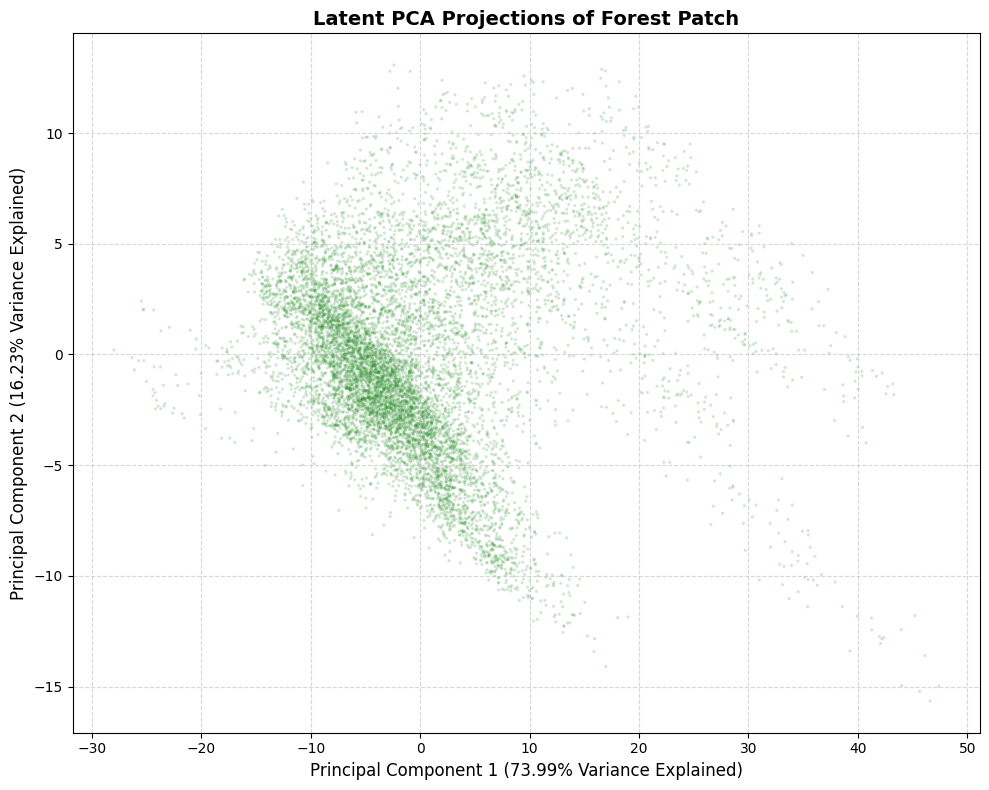

In [8]:
# Forrest-patch is fetched from the above cell

h, w, bands = forest_patch.shape
num_pixels = h * w

# Flatten from 3D (128, 128, B) to 2D (16384, B)
flattened_pixels = forest_patch.reshape(num_pixels, bands)

# Optional but recommended: Standardize the features (bands)
# This ensures bands with larger numerical ranges don't dominate the PCA
scaler = StandardScaler()
scaled_pixels = scaler.fit_transform(flattened_pixels)

# --- 2. Fit the PCA model ---
# We only need 2 components for a 2D scatter plot
pca = PCA(n_components=2)
latent_projections = pca.fit_transform(scaled_pixels)

# --- 3. Extract Explained Variance ---
# Convert the ratios to percentages for the plot labels
explained_variance = pca.explained_variance_ratio_ * 100
var_pc1 = explained_variance[0]
var_pc2 = explained_variance[1]

# --- 4. Plot the Latent Projections ---
plt.figure(figsize=(10, 8))

# Using a low 'alpha' (transparency) is crucial here. 
# You are plotting 16,384 points, and they will overplot into a solid blob otherwise.
plt.scatter(
    latent_projections[:, 0], 
    latent_projections[:, 1], 
    alpha=0.2,   # Transparency to see density
    s=5,         # Small dot size
    c='forestgreen',
    edgecolors='none'
)

# Labeling with the captured variance
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variance Explained)', fontsize=12)
plt.title('Latent PCA Projections of Forest Patch', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Training and initializing the becnhline OAMFA

In [9]:
# Initialize the OAMFA model
print(f"Type of img_train: {type(img_train)}")
if img_train is None:
    print("Warning: img_train failed to load!")

# Your original code:
img_train = img_train.reshape(-1, img_train.shape[-1])  # Flatten to (num_pixels, num_bands)
num_samples = min(100000, img_train.shape[0])  # Limit to 100k samples for trainin to reduce timing

# Sample a random subset of pixels for training to reduce computational load
np.random.seed(42)  # For reproducibility during thesis drafting
sample_indices = np.random.choice(img_train.shape[0], size=num_samples, replace=False)
img_train_sampled = img_train[sample_indices]

MFA_OTFP_model=MFA_OTFP(
    init_data=torch.tensor(img_train_sampled, dtype=torch.float32),
    n_channels=120, 
    device="cpu", 
    outlier_update_treshold=2000,
    q_max=6,
    K_max=5,
    L2_normalization=True
)

Type of img_train: <class 'numpy.ndarray'>
Starting Bayesian model selection with K_max=5, q_max=6...
Theoretical Chi-Square threshold initialized: 186.33
Finished setup of OTFP-MFA: K=2, q=4


## Test nr 1 *Novel Material Spawning*

First we stream the pretrained model on the unseen data

In [10]:
import copy

print("--- INITIALIZING NOVEL MATERIAL TEST ---")

# 1. Clone the pretrained model to keep the original intact for the next test
print("Deepcopying the pretrained OAMFA model...")
novel_test_model = copy.deepcopy(MFA_OTFP_model)

# Record baseline for comparison later
baseline_k = novel_test_model.MFA.K
print(f"Baseline Components (K): {baseline_k}")

# 2. Setup streaming parameters simulating push-broom capture
h, w, d = test_img_forest.shape
batch_frames = 22  # Simulating 1 second of flight/capture per batch
device = novel_test_model.device 

print(f"Streaming hyperspectral data (Shape: {test_img_forest.shape}) in chunks of {batch_frames} lines...")

# 3. Stream the data block-by-block
novel_test_model.MFA.train() # Ensure model is in training mode for updates

for i in range(0, h, batch_frames):
    # Slice the 3D cube to grab the next batch of lines
    batch_3d = test_img_forest[i : i + batch_frames, :, :]
    current_batch_lines = batch_3d.shape[0]
    
    # Flatten the spatial dimensions: (lines * width, bands)
    batch_flat = batch_3d.reshape(current_batch_lines * w, d)
    
    # Convert to tensor and push to device
    batch_tensor = torch.tensor(batch_flat, dtype=torch.float32).to(device)
    
    # Update the OAMFA model
    novel_test_model.process_data_block(X=batch_tensor)

print("\n--- STREAMING COMPLETE ---")
final_k = novel_test_model.MFA.K
print(f"Final Components (K): {final_k}")
print(f"Total New Components Spawned: {final_k - baseline_k}")

--- INITIALIZING NOVEL MATERIAL TEST ---
Deepcopying the pretrained OAMFA model...
Baseline Components (K): 2
Streaming hyperspectral data (Shape: (478, 684, 120)) in chunks of 22 lines...
Model successfully updated! Total components (K) is now 3

Successfully birthed 1 new components this cycle.

--- STREAMING COMPLETE ---
Final Components (K): 3
Total New Components Spawned: 1


--- GENERATING VALIDATION PLOTS ---
Evaluating Pretrained Model...
Evaluating Streamed Model...


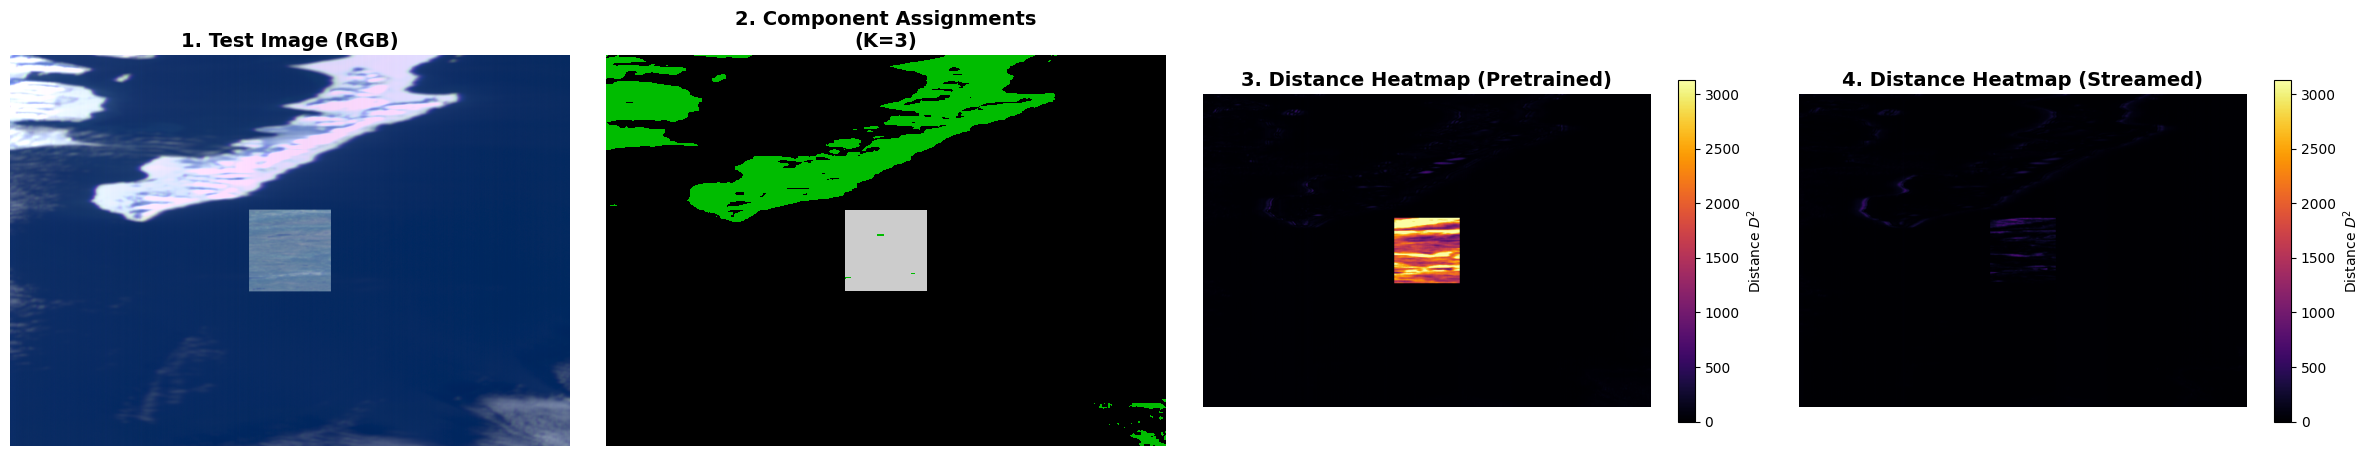

In [ ]:
print("--- GENERATING VALIDATION PLOTS ---")

# --- 1. Prepare the Data ---
h, w, d = test_img_forest.shape
data_2d_full = test_img_forest.reshape(-1, d)
data_2d_full_tensor = torch.tensor(data_2d_full, dtype=torch.float32).to(device)

# Apply L2 Normalization (matching your MFA_OTFP init)
L2_NORMALIZATION = True 
if L2_NORMALIZATION:
    norms = torch.norm(data_2d_full_tensor, p=2, dim=1, keepdim=True)
    epsilon = 1e-8
    processed_image = data_2d_full_tensor / (norms + epsilon)
else:
    processed_image = data_2d_full_tensor

# --- 2. Helper: Calculate Mahalanobis Distance & Assignments ---
def get_mahalanobis_and_assignments(otfp_model, X_tensor):
    """
    Retrieves the E-step responsibilities and pre-computed Mahalanobis distances
    directly from your optimized MFA class.
    """
    with torch.no_grad():
        # Your e_step elegantly returns: log_resp_norm, log_likelihood, log_probs, mahalanobis_dists
        log_resp, _, _, mahalanobis_dists = otfp_model.MFA.e_step(X_tensor)
        
        # The best-fit component for each pixel (raw argmax, no masking)
        best_components = torch.argmax(log_resp, dim=1)
        
        # Distance to the closest component
        min_dist, _ = torch.min(mahalanobis_dists, dim=1)
        
    return min_dist.cpu().numpy(), best_components.cpu().numpy()

# --- 3. Run Inference (Before and After) ---
# BASELINE (Pre-trained model)
print("Evaluating Pretrained Model...")
dist_before, _ = get_mahalanobis_and_assignments(MFA_OTFP_model, processed_image)

# UPDATED (Streamed model)
print("Evaluating Streamed Model...")
dist_after, assign_after = get_mahalanobis_and_assignments(novel_test_model, processed_image)

# Reshape back to 2D image dimensions
heatmap_before = dist_before.reshape(h, w)
heatmap_after = dist_after.reshape(h, w)
seg_map = assign_after.reshape(h, w)  # No artificial masking here. Let the model speak for itself.

# --- 4. Plotting ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# A) RGB True Color (with global Gamma correction)
def get_rgb_gamma(hsi_cube):
    r, g, b = hsi_cube[:, :, 70], hsi_cube[:, :, 50], hsi_cube[:, :, 20]
    rgb = np.stack([r, g, b], axis=-1)
    p_low, p_high = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
    rgb_norm = np.clip((rgb - p_low) / (p_high - p_low + 1e-8), 0, 1)
    return rgb_norm ** 0.6 # Gamma lift

axes[0].imshow(get_rgb_gamma(test_img_forest), aspect='equal')
axes[0].set_title("1. Test Image (RGB)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# B) Component Assignment Map
# Plot pure segmentation
cax1 = axes[1].imshow(seg_map, cmap='nipy_spectral', vmin=0, vmax=novel_test_model.MFA.K - 1, interpolation='nearest', aspect='equal')
axes[1].set_title(f"2. Component Assignments\n(K={novel_test_model.MFA.K})", fontweight='bold', fontsize=14)
axes[1].axis('off')

# C) Mahalanobis Distance Heatmap (Pretrained)
max_dist_plot = np.percentile(dist_before, 99.5) # Cap extreme spikes for visual clarity

cax2 = axes[2].imshow(heatmap_before, cmap='inferno', vmin=0, vmax=max_dist_plot, aspect='equal')
axes[2].set_title("3. Distance Heatmap (Pretrained)", fontweight='bold', fontsize=14)
axes[2].axis('off')
fig.colorbar(cax2, ax=axes[2], shrink=0.6, label='Distance $D^2$')

# D) Mahalanobis Distance Heatmap (Streamed)
cax3 = axes[3].imshow(heatmap_after, cmap='inferno', vmin=0, vmax=max_dist_plot, aspect='equal')
axes[3].set_title("4. Distance Heatmap (Streamed)", fontweight='bold', fontsize=14)
axes[3].axis('off')
fig.colorbar(cax3, ax=axes[3], shrink=0.6, label='Distance $D^2$')

plt.tight_layout()
plt.show()

## Test nr2 *Noise Rejection*
First we stream the pretrained model on the unseen data

In [12]:
import copy

print("--- INITIALIZING NOVEL MATERIAL TEST ---")

# 1. Clone the pretrained model to keep the original intact for the next test
print("Deepcopying the pretrained OAMFA model...")
noise_test_model = copy.deepcopy(MFA_OTFP_model)

# Record baseline for comparison later
baseline_k = noise_test_model.MFA.K
print(f"Baseline Components (K): {baseline_k}")

# 2. Setup streaming parameters simulating push-broom capture
h, w, d = test_img_noise.shape
batch_frames = 22  # Simulating 1 second of flight/capture per batch
device = noise_test_model.device 

print(f"Streaming hyperspectral data (Shape: {test_img_noise.shape}) in chunks of {batch_frames} lines...")

# 3. Stream the data block-by-block
noise_test_model.MFA.train() # Ensure model is in training mode for updates

for i in range(0, h, batch_frames):
    # Slice the 3D cube to grab the next batch of lines
    batch_3d = test_img_noise[i : i + batch_frames, :, :]
    current_batch_lines = batch_3d.shape[0]
    
    # Flatten the spatial dimensions: (lines * width, bands)
    batch_flat = batch_3d.reshape(current_batch_lines * w, d)
    
    # Convert to tensor and push to device
    batch_tensor = torch.tensor(batch_flat, dtype=torch.float32).to(device)
    
    # Update the OAMFA model
    noise_test_model.process_data_block(X=batch_tensor)

print("\n--- STREAMING COMPLETE ---")
final_k = noise_test_model.MFA.K
print(f"Final Components (K): {final_k}")
print(f"Total New Components Spawned: {final_k - baseline_k}")

--- INITIALIZING NOVEL MATERIAL TEST ---
Deepcopying the pretrained OAMFA model...
Baseline Components (K): 2
Streaming hyperspectral data (Shape: (478, 684, 120)) in chunks of 22 lines...
Model successfully updated! Total components (K) is now 3

Successfully birthed 1 new components this cycle.
Shelf full, but only contained scattered noise. Burning shelf.

--- STREAMING COMPLETE ---
Final Components (K): 3
Total New Components Spawned: 1


--- GENERATING VALIDATION PLOTS ---
Evaluating Pretrained Model...
Evaluating Streamed Model...


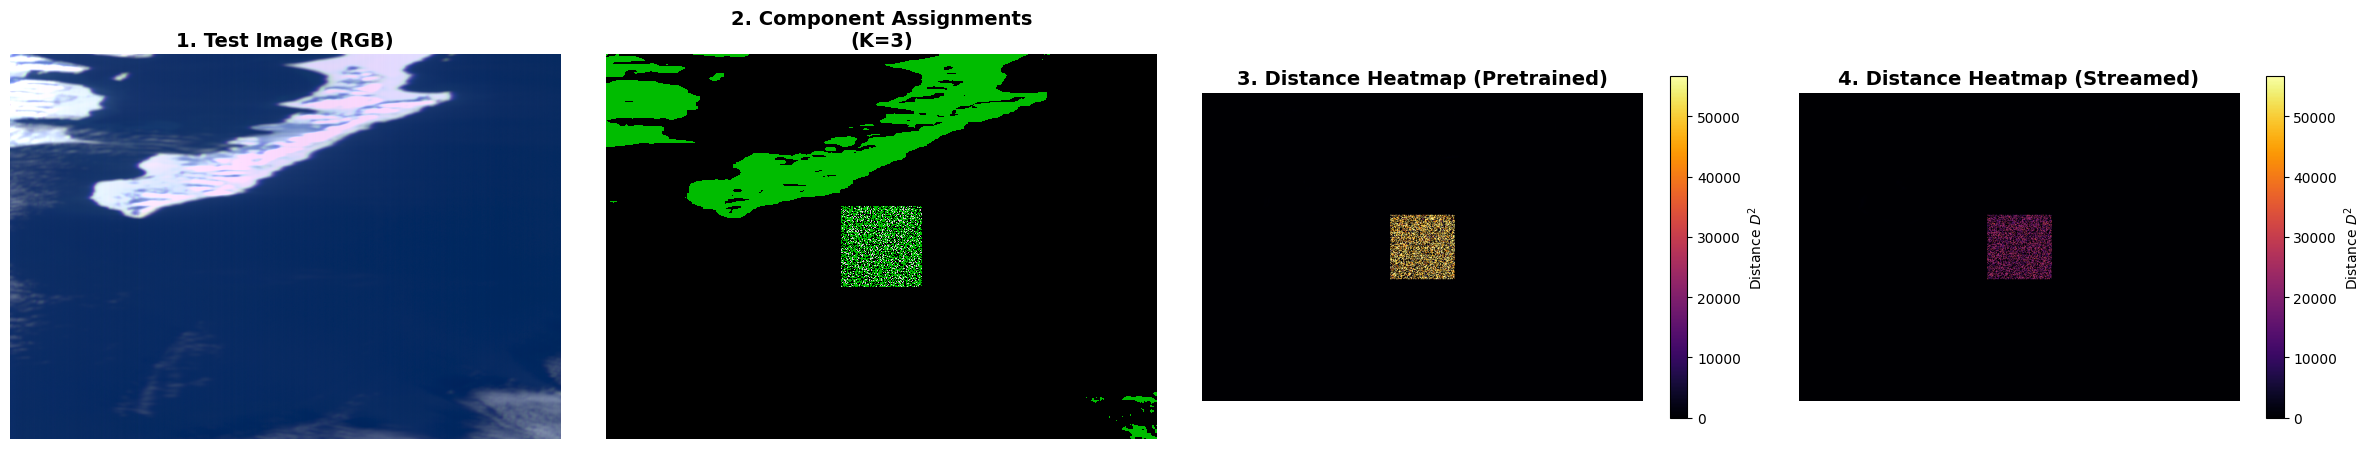

In [13]:
print("--- GENERATING VALIDATION PLOTS ---")

# --- 1. Prepare the Data ---
h, w, d = test_img_noise.shape
data_2d_full = test_img_noise.reshape(-1, d)
data_2d_full_tensor = torch.tensor(data_2d_full, dtype=torch.float32).to(device)

# Apply L2 Normalization (matching your MFA_OTFP init)
L2_NORMALIZATION = True 
if L2_NORMALIZATION:
    norms = torch.norm(data_2d_full_tensor, p=2, dim=1, keepdim=True)
    epsilon = 1e-8
    processed_image = data_2d_full_tensor / (norms + epsilon)
else:
    processed_image = data_2d_full_tensor

# --- 2. Helper: Calculate Mahalanobis Distance & Assignments ---
def get_mahalanobis_and_assignments(otfp_model, X_tensor):
    """
    Retrieves the E-step responsibilities and pre-computed Mahalanobis distances
    directly from your optimized MFA class.
    """
    with torch.no_grad():
        # Your e_step elegantly returns: log_resp_norm, log_likelihood, log_probs, mahalanobis_dists
        log_resp, _, _, mahalanobis_dists = otfp_model.MFA.e_step(X_tensor)
        
        # The best-fit component for each pixel (raw argmax, no masking)
        best_components = torch.argmax(log_resp, dim=1)
        
        # Distance to the closest component
        min_dist, _ = torch.min(mahalanobis_dists, dim=1)
        
    return min_dist.cpu().numpy(), best_components.cpu().numpy()

# --- 3. Run Inference (Before and After) ---
# BASELINE (Pre-trained model)
print("Evaluating Pretrained Model...")
dist_before, _ = get_mahalanobis_and_assignments(MFA_OTFP_model, processed_image)

# UPDATED (Streamed model)
print("Evaluating Streamed Model...")
dist_after, assign_after = get_mahalanobis_and_assignments(novel_test_model, processed_image)

# Reshape back to 2D image dimensions
heatmap_before = dist_before.reshape(h, w)
heatmap_after = dist_after.reshape(h, w)
seg_map = assign_after.reshape(h, w)  # No artificial masking here. Let the model speak for itself.

# --- 4. Plotting ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# A) RGB True Color (with global Gamma correction)
def get_rgb_gamma(hsi_cube):
    r, g, b = hsi_cube[:, :, 70], hsi_cube[:, :, 50], hsi_cube[:, :, 20]
    rgb = np.stack([r, g, b], axis=-1)
    p_low, p_high = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
    rgb_norm = np.clip((rgb - p_low) / (p_high - p_low + 1e-8), 0, 1)
    return rgb_norm ** 0.6 # Gamma lift

axes[0].imshow(get_rgb_gamma(test_img_noise), aspect='equal')
axes[0].set_title("1. Test Image (RGB)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# B) Component Assignment Map
# Plot pure segmentation
cax1 = axes[1].imshow(seg_map, cmap='nipy_spectral', vmin=0, vmax=novel_test_model.MFA.K - 1, interpolation='nearest', aspect='equal')
axes[1].set_title(f"2. Component Assignments\n(K={novel_test_model.MFA.K})", fontweight='bold', fontsize=14)
axes[1].axis('off')

# C) Mahalanobis Distance Heatmap (Pretrained)
max_dist_plot = np.percentile(dist_before, 99.5) # Cap extreme spikes for visual clarity

cax2 = axes[2].imshow(heatmap_before, cmap='inferno', vmin=0, vmax=max_dist_plot, aspect='equal')
axes[2].set_title("3. Distance Heatmap (Pretrained)", fontweight='bold', fontsize=14)
axes[2].axis('off')
fig.colorbar(cax2, ax=axes[2], shrink=0.6, label='Distance $D^2$')

# D) Mahalanobis Distance Heatmap (Streamed)
cax3 = axes[3].imshow(heatmap_after, cmap='inferno', vmin=0, vmax=max_dist_plot, aspect='equal')
axes[3].set_title("4. Distance Heatmap (Streamed)", fontweight='bold', fontsize=14)
axes[3].axis('off')
fig.colorbar(cax3, ax=axes[3], shrink=0.6, label='Distance $D^2$')

plt.tight_layout()
plt.show()